# Notebook 10 — Many tests

*SWC ENC 2026 · behaviour module · Part 2 (population-level inference)*

Modular and skippable, like the rest of Part 2.

Real analyses rarely run one test — they run dozens. The moment you screen many
candidate effects at once — several predictors, many conditions, or every strategy
in the design matrix — some will look "significant" by pure chance, and you have to
account for it. This notebook builds that toolkit on a controlled problem where **we
know which effects are real**, so we can *measure* whether a correction actually
works — something you can never do on real data.

**In this notebook you will:**
1. Run a **t-test** and see exactly what its p-value means.
2. Watch false positives pile up when you run **many** tests.
3. Control them two ways — **Bonferroni** (FWER) and **Benjamini–Hochberg** (FDR) —
   and measure the difference.

## Setup

We simulate a batch of independent "candidate effects" — think of them as many
possible behavioural predictors we're screening. Each is measured in `n_mice`
animals. **Most candidates are truly null** (real effect exactly 0); a handful are
real. Because we set which is which, we can later grade every method against the
truth. This cell always runs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import swcbehav as sb

rng = np.random.default_rng(0)
n_mice, n_tests, n_real = 15, 200, 20
true_effect = np.zeros(n_tests)
true_effect[:n_real] = 0.9                       # the first 20 candidates are real
is_real = true_effect > 0

# each mouse measures each candidate with noise
data = true_effect[None, :] + rng.normal(0, 1, size=(n_mice, n_tests))
print(f"{n_tests} candidates ({n_real} real, {n_tests - n_real} null), {n_mice} mice each")

200 candidates (20 real, 180 null), 15 mice each


## 1. One t-test

A one-sample **t-test** asks: is a mean different from a reference value (here, 0),
*relative to how noisy the measurement is?* The statistic is signal over noise,

$$t = \frac{\bar{x} - 0}{s / \sqrt{n}},$$

where $\bar{x}$ is the sample mean, $s$ its standard deviation, and $n$ the number of
mice. A large $|t|$ means the mean is many standard errors from 0 — hard to explain
as noise. The **p-value** turns $|t|$ into a probability: *if the true mean were 0,
how often would we see a $t$ this extreme?* We read it from the t-distribution.

**Exercise 1** *(~5 min)*. Complete `one_sample_t`. Compute $t$ yourself; get the two-sided
p-value from `stats.t.sf` (the survival function, $1-\text{CDF}$) with `n-1` degrees
of freedom.

> **Check / unstuck.** The real candidate should give a small p (~0.006), the null
> one a larger p. Stuck? `scipy.stats.ttest_1samp(x, 0)` returns `(t, p)`.

In [2]:
def one_sample_t(x):
    x = np.asarray(x, float)
    n = len(x)
    t = x.mean() / (x.std(ddof=1) / np.sqrt(n))
    p = 2 * stats.t.sf(abs(t), df=n - 1)          # two-sided
    return t, p

print("a REAL candidate :", [round(v, 4) for v in one_sample_t(data[:, 0])])
print("a NULL candidate :", [round(v, 4) for v in one_sample_t(data[:, -1])])

a REAL candidate : [np.float64(3.2656), np.float64(0.0056)]
a NULL candidate : [np.float64(-1.8621), np.float64(0.0837)]


The real candidate has a small p-value; the null one (usually) doesn't. Now compute a
p-value for **every** candidate — `scipy` will do all 200 at once.

In [3]:
tvals, pvals = stats.ttest_1samp(data, popmean=0, axis=0)
print("first few p-values:", np.round(pvals[:5], 4))

first few p-values: [0.0056 0.0334 0.0094 0.002  0.2582]


## 2. The problem with many tests

At a threshold of $\alpha = 0.05$, each *null* candidate still has a 5% chance of
looking "significant" by luck. With many nulls, those add up. Count how many of our
**truly null** candidates cross $p < 0.05$:

In [4]:
raw_hits = pvals < 0.05
false_positives = np.sum(raw_hits & ~is_real)
print(f"'significant' at p<0.05: {raw_hits.sum()} candidates")
print(f"  of which FALSE positives (truly null): {false_positives}")
print(f"  expected by chance: {0.05 * (n_tests - n_real):.0f}")

'significant' at p<0.05: 29 candidates
  of which FALSE positives (truly null): 11
  expected by chance: 9


Those false positives are the price of many tests. Two philosophies control it:

- **Bonferroni** controls the **family-wise error rate** (FWER) — the chance of
  *even one* false positive — by testing each candidate at $\alpha/m$. Safe, but so
  strict it also throws away real effects.
- **Benjamini–Hochberg** controls the **false discovery rate** (FDR) — the *expected
  fraction of your "discoveries" that are false*. More permissive, keeps more real
  effects, and it's the correction Piet et al. use.

## 3. Benjamini–Hochberg

Sort the $m$ p-values ascending, $p_{(1)} \le \dots \le p_{(m)}$. Find the largest
rank $k$ with $p_{(k)} \le \frac{k}{m}\alpha$, and reject everything up to it. The
sliding threshold $\frac{k}{m}\alpha$ is lenient for the smallest p-values and
tightens toward $\alpha$ — that's what trades a controlled FDR for more power.

*Worked example:* with $m=5$ p-values $[0.001, 0.20, 0.01, 0.50, 0.04]$, sort to
$[0.001, 0.01, 0.04, 0.20, 0.50]$ and compare each to $\frac{k}{5}\cdot 0.05 =
[0.01, 0.02, 0.03, 0.04, 0.05]$: ranks 1 and 2 pass ($0.001\le 0.01$, $0.01\le 0.02$),
rank 3 fails ($0.04 > 0.03$). The **largest** rank that passes is $k=2$, so you
reject the two smallest p-values.

**Exercise 2** *(~8 min · meaty)*. Complete `benjamini_hochberg`; it returns a boolean "rejected" mask.

> **Check / unstuck.** Expect **BH to reject ~9** candidates (matches the backend).
> Stuck? Use `sb.benjamini_hochberg(pvals, 0.05)`.

In [5]:
def benjamini_hochberg(pvals, alpha=0.05):
    pvals = np.asarray(pvals, float)
    m = len(pvals)
    order = np.argsort(pvals)
    thresholds = alpha * np.arange(1, m + 1) / m
    passing = pvals[order] <= thresholds
    rejected = np.zeros(m, dtype=bool)
    if passing.any():
        kmax = np.max(np.flatnonzero(passing))
        rejected[order[: kmax + 1]] = True
    return rejected

print("BH rejects", benjamini_hochberg(pvals).sum(), "candidates")
print("backend check:", sb.benjamini_hochberg(pvals).sum())

BH rejects 9 candidates
backend check: 9


It helps to *see* what BH does. Plot the sorted p-values against their rank, with the
sliding threshold $k\alpha/m$ (the BH line) and, for contrast, the flat uncorrected
$\alpha$. BH keeps everything up to the last point that lies **below** the sloped
line — a cutoff stricter than the naive $\alpha$ but far more forgiving than
Bonferroni's $\alpha/m$.

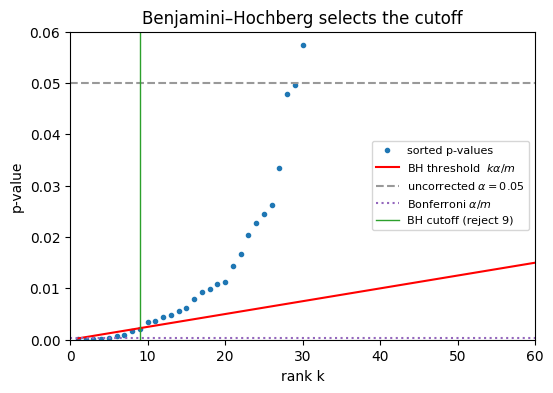

In [6]:
m = len(pvals)
srt = np.sort(pvals)
k = np.arange(1, m + 1)
n_rej = sb.benjamini_hochberg(pvals, 0.05).sum()
plt.figure(figsize=(6, 4))
plt.plot(k, srt, "o", ms=3, label="sorted p-values")
plt.plot(k, 0.05 * k / m, "r-", label=r"BH threshold  $k\alpha/m$")
plt.axhline(0.05, color="0.6", ls="--", label=r"uncorrected $\alpha=0.05$")
plt.axhline(0.05 / m, color="tab:purple", ls=":", label=r"Bonferroni $\alpha/m$")
plt.axvline(n_rej, color="tab:green", lw=1, label=f"BH cutoff (reject {n_rej})")
plt.xlim(0, 60); plt.ylim(0, 0.06)
plt.xlabel("rank k"); plt.ylabel("p-value"); plt.legend(fontsize=8)
plt.title("Benjamini–Hochberg selects the cutoff")
plt.show()

## 4. Grading the methods against the truth

Here's the payoff of synthetic data: we know `is_real`, so we can measure each
method's **power** (fraction of real effects caught) and its **false-discovery
rate** (fraction of discoveries that are actually null). But a *single* experiment
is noisy, and FDR is only controlled *on average* — so we run many simulated
experiments and average.

In [7]:
def run_experiment(seed):
    r = np.random.default_rng(seed)
    d = true_effect[None, :] + r.normal(0, 1, size=(n_mice, n_tests))
    _, pv = stats.ttest_1samp(d, 0, axis=0)
    return {"no correction":      pv < 0.05,
            "Bonferroni":         pv < 0.05 / n_tests,
            "BH":                 sb.benjamini_hochberg(pv, 0.05)}

def fdr_power(rej):
    n = rej.sum()
    return np.sum(rej & ~is_real) / max(n, 1), np.sum(rej & is_real) / is_real.sum()

reps = [run_experiment(s) for s in range(300)]
print(f"{'method':16s}{'mean FDR':>10}{'mean power':>12}")
for name in ["no correction", "Bonferroni", "BH"]:
    fdrs = np.mean([fdr_power(r[name])[0] for r in reps])
    powers = np.mean([fdr_power(r[name])[1] for r in reps])
    print(f"{name:16s}{fdrs:>10.3f}{powers:>12.2f}")

method            mean FDR  mean power
no correction        0.327        0.90
Bonferroni           0.009        0.18
BH                   0.048        0.48


Averaged over experiments the picture is clean: **no correction** runs a
false-discovery rate far above 0.05; **Bonferroni** drives false discoveries nearly
to zero but sacrifices power; **BH** holds the mean FDR at or just under the target
0.05 while catching far more of the real effects than Bonferroni. That balance — a
controlled false-discovery rate with usable power — is why the paper (and most of
modern neuroscience) reaches for Benjamini-Hochberg when screening many comparisons.

## Wrap-up

You built a t-test from its definition, saw why many tests inflate false positives,
and measured how Bonferroni and Benjamini–Hochberg control them. The one piece of
structure we set aside here was **nesting** — we treated each mouse's measurement as
one independent number. The last notebook confronts nesting head-on.

**Next (Notebook 11):** honest error bars for nested data — the hierarchical
bootstrap.